# Regressão Softmax com dados do MNIST utilizando gradiente descendente estocástico por minibatches

O objetivo deste notebook é ilustrar
- o uso do gradiente estocástico por mini-batchs
- utilizando as classes Dataset e DataLoater.

A apresentação da perda nos gráficos é um pouco diferente da usual, mostrando a perda de cada um dos vários minibatches dentro de cada época, de forma que as épocas são apresentadas com valores fracionários.

## Importação das bibliotecas

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.autograd import Variable
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import MNIST

## Dataset e dataloader

### Definição do tamanho do minibatch

In [2]:
batch_size = 100

In [ ]:
#(50, 100, 200, 500)

### Carregamento, criação dataset e do dataloader

### Usando apenas 1000 amostras do MNIST

Neste exemplo utilizaremos 1000 amostras de treinamento.

In [3]:
dataset_dir = 'MNIST/'

dataset_train = MNIST(dataset_dir, train=True, download=True,
                      transform=torchvision.transforms.ToTensor())

loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

print('Número de minibatches de trenamento:', len(loader_train))

x_train, y_train = next(iter(loader_train))
print("\nDimensões dos dados de um minibatch:", x_train.size())
print("Valores mínimo e máximo dos pixels: ", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:         ", type(x_train))
print("Tipo das classes das imagens:       ", type(y_train))

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.05MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]

Número de minibatches de trenamento: 600

Dimensões dos dados de um minibatch: torch.Size([100, 1, 28, 28])
Valores mínimo e máximo dos pixels:  tensor(0.) tensor(1.)
Tipo dos dados das imagens:          <class 'torch.Tensor'>
Tipo das classes das imagens:        <class 'torch.Tensor'>


In [4]:
len(loader_train)

600

In [5]:
print('Número de minibatches de trenamento:', len(loader_train))
n_batches_train = len(loader_train)
total_samples = len(dataset_train)

Número de minibatches de trenamento: 600


## Modelo

In [6]:
model = torch.nn.Linear(28*28, 10)


In [7]:
x = torch.ones(28*28).reshape(1, 784)
print(x.shape)
predict = model(x)
predict

torch.Size([1, 784])


tensor([[ 0.2971, -0.2452,  0.8017,  0.4478, -0.3286,  0.5274, -0.0698, -0.9648,
         -0.9245, -0.1150]], grad_fn=<AddmmBackward0>)

In [8]:
x_train, y_train = next(iter(loader_train))
pred = model(x_train.view(-1, 784))
pred

tensor([[ 9.0738e-02, -1.0495e-01,  3.4339e-01,  3.8900e-01, -4.9462e-02,
          3.7985e-01,  1.9033e-01, -3.5410e-02, -4.1983e-01,  3.9085e-01],
        [ 4.9081e-03,  2.2808e-01,  1.2375e-01,  1.4191e-01, -4.6270e-02,
          9.8342e-02, -3.0313e-01, -3.4723e-02,  1.2522e-01,  2.6515e-01],
        [ 3.7789e-01,  2.2627e-01,  5.1469e-01,  2.0606e-01,  9.5675e-02,
          3.6610e-01,  1.4884e-01, -3.1011e-02, -4.3729e-01,  3.7412e-01],
        [ 2.9350e-02,  7.4483e-02,  1.8085e-01,  1.5341e-01,  5.4799e-02,
         -2.0599e-02, -5.9971e-02, -2.9548e-02, -3.9386e-01,  1.9744e-01],
        [ 1.4514e-02,  1.3619e-01,  2.1264e-01,  5.3039e-01, -9.9665e-02,
         -4.3334e-02,  2.6693e-01, -1.6532e-02, -1.2440e-01,  3.2327e-01],
        [ 1.9771e-01,  1.0275e-01,  6.6492e-02,  3.6370e-02,  2.2524e-02,
          1.1034e-01,  5.1734e-02,  1.2356e-01, -2.9043e-01,  3.6514e-01],
        [-1.0948e-01, -3.9408e-04,  6.6850e-02,  3.0320e-01, -1.8229e-01,
          2.0920e-01,  2.1155e-0

## Treinamento

### Inicialização dos parâmetros

In [9]:
n_epochs = 5
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos parâmetros

In [18]:
epochs = []
losses = []
losses_epoch = []
best_loss_epoch = 100

n_batches_train = len(loader_train)

total_trained_samples = 0
for i in range(n_epochs):
    for k,(x_train, y_train) in enumerate(loader_train):
        # Transforma a entrada para uma dimensão
        inputs = x_train.view(-1, 28 * 28)
        # predict da rede
        outputs = model(inputs)

        # calcula a perda
        loss = criterion(outputs, y_train)

        # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_trained_samples += x_train.size(0)
        epochs.append(total_trained_samples / total_samples)
        losses.append(loss.data)
        if loss.data < best_loss_epoch:
            best_loss_epoch = loss.data
        losses_epoch.append(best_loss_epoch)

         # 👉 PRINT DO EXERCÍCIO 1

        print(f"Época: {i+1}/{n_epochs}, batch: {k+1}/{n_batches_train}")


Época: 1/5, batch: 1/600
Época: 1/5, batch: 2/600
Época: 1/5, batch: 3/600
Época: 1/5, batch: 4/600
Época: 1/5, batch: 5/600
Época: 1/5, batch: 6/600
Época: 1/5, batch: 7/600
Época: 1/5, batch: 8/600
Época: 1/5, batch: 9/600
Época: 1/5, batch: 10/600
Época: 1/5, batch: 11/600
Época: 1/5, batch: 12/600
Época: 1/5, batch: 13/600
Época: 1/5, batch: 14/600
Época: 1/5, batch: 15/600
Época: 1/5, batch: 16/600
Época: 1/5, batch: 17/600
Época: 1/5, batch: 18/600
Época: 1/5, batch: 19/600
Época: 1/5, batch: 20/600
Época: 1/5, batch: 21/600
Época: 1/5, batch: 22/600
Época: 1/5, batch: 23/600
Época: 1/5, batch: 24/600
Época: 1/5, batch: 25/600
Época: 1/5, batch: 26/600
Época: 1/5, batch: 27/600
Época: 1/5, batch: 28/600
Época: 1/5, batch: 29/600
Época: 1/5, batch: 30/600
Época: 1/5, batch: 31/600
Época: 1/5, batch: 32/600
Época: 1/5, batch: 33/600
Época: 1/5, batch: 34/600
Época: 1/5, batch: 35/600
Época: 1/5, batch: 36/600
Época: 1/5, batch: 37/600
Época: 1/5, batch: 38/600
Época: 1/5, batch: 39

In [11]:
print('Final loss:', loss.data)

Final loss: tensor(0.1748)


### Visualizando gráfico de perda durante o treinamento

Text(0.5, 0, 'época')

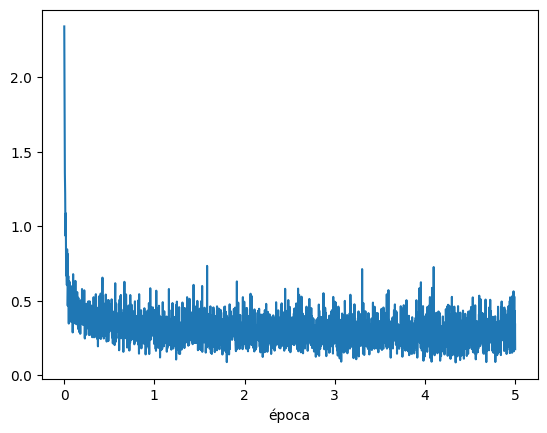

In [12]:
plt.plot(epochs, losses)
plt.xlabel('época')

In [13]:
n_epochs

5

Text(0.5, 0, 'época')

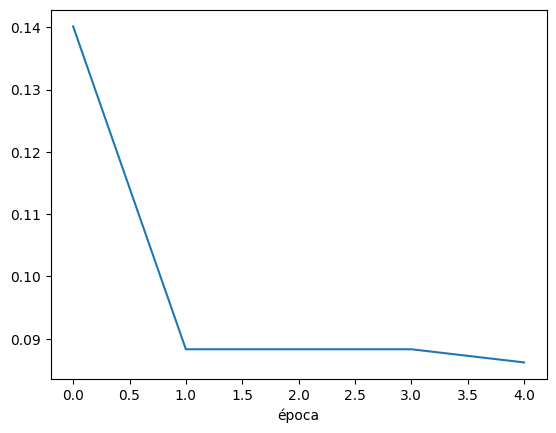

In [14]:
losses_for_plot = []
for epoch_idx in range(n_epochs):
    losses_for_plot.append(losses_epoch[(epoch_idx + 1) * n_batches_train - 1])

plt.plot(range(n_epochs), losses_for_plot)
plt.xlabel('época')

### Visualização usual da perda, somente no final de cada minibatch

Text(0.5, 0, 'época')

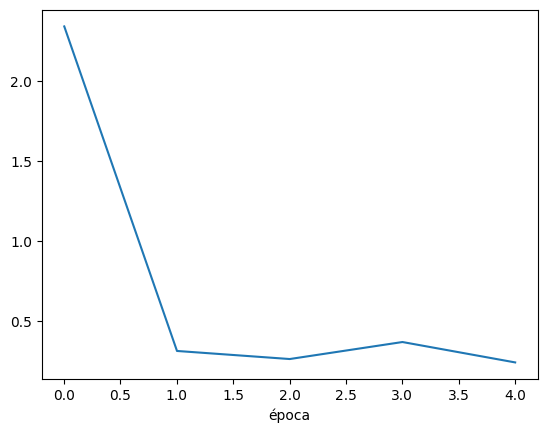

In [15]:
plt.plot(epochs[:5 * n_batches_train +1:n_batches_train], losses[:5 * n_batches_train+1:n_batches_train])
plt.xlabel('época')

# Atividades

## Perguntas

1. Qual é o tamanho do mini-batch?
R: 100
2. Em uma época, quantos mini-batches existem?
R: 600
3. Qual é a definição de época?
R: 1 passagem completa por todo o conjunto de dados de treinamento

## Exercícios


1. Coloque um print no final de cada minibatch, no mesmo estilo do print do final de época, no seguinte estilo:
    - Época: 1/4, batch: 3/10
2. Altere o tamanho de minibatch (batch_size) algumas vezes, refaça o treinamento, e compare no gráfico abaixo a queda da perda para cada tamanho de minibatch.

## Conclusões sobre os experimentos deste notebook


1. O mini-batch contribui com a rapidez da convergência, num mesmo número de épocas
2. Os resultado pode ser mais ruidoso
